In [1]:
#import relevant libraries
import os
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap


import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 18.26it/s]


Numba compilation complete!


In [2]:
#initial file processing
workcomp = "C:\\Users\\User"
computer2 = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
titledpath = homecomp
openPath = titledpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "ACR"
respondercsv = responder + ".csv"
wt = "w1118"


In [3]:
lstnew=[]


for file_no in os.listdir(openPath): 
    if respondercsv in file_no and "w1118" not in file_no :   #wt > acr files
        f = os.path.join(openPath, file_no)
        dfe=pd.read_csv(f)
        exptdf = dfe.drop(dfe.columns[[0]],axis = 1)
        driver = file_no.split(" ")[0]
        lstnew.append(driver)

## functions

In [4]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

[f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Fira Mono"

In [5]:
def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

def wrap_labels(ax, width, break_long_words=False):
    import textwrap
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc

In [6]:
newfile2 = openPath + "Compilation with delta\\2025meandiffcollection\\"
files2 = os.listdir(newfile2)
totalfile = pd.DataFrame()

for n in files2:
    
    openfile = pd.read_csv(newfile2 + n)
    nameofmbon = n.split(" ")[0] 
    openfile['responder'] = n.split(" ")[2]
    totalfile = pd.concat([totalfile, openfile], axis = 0).reset_index(drop=True)

lstofallvariables = []
for n in totalfile.columns.to_list()[1:-1]:
    lstofallvariables.append(n.split("_")[0])
lstnamings= list(set(lstofallvariables))

totalfile['genotypeandresponder'] = totalfile["MBON"] + "_" + totalfile['responder']   #has bootstraps

#only delta-g
onlymeans = totalfile.loc[:, ~totalfile.columns.str.endswith('_bootstrap')].drop_duplicates().reset_index(drop=True)

mbononly=onlymeans[~onlymeans['MBON'].isin(['R58', 'Th-Gal4'])]

# specificmetrics = ['MBON', 'bspeed_deltag', 'speed_deltag', 'fallprop_deltag', 'fallnumber_deltag',  'height_deltag', 'maxvelocity_deltag', 'straightindex_deltag', 'pause_deltag', 'meanpause_deltag',
#                    'responder', 'genotypeandresponder']

# eightmetrics = pd.DataFrame()
# for p in specificmetrics:
#     eightmetrics = pd.concat([eightmetrics, mbononly[p]], axis =1) 
# eightmetrics = eightmetrics.reset_index(drop=True)


In [7]:
#lobe location

files2 = os.listdir(newfile2)

MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

#reading mbonlist file
directorynew = os.path.dirname(os.path.dirname(openPath)) #goes up one directory
fileinnewdirc = os.listdir(directorynew)

for file_no2 in fileinnewdirc:
    if ".csv" in file_no2:
        ff = os.path.join(directorynew, file_no2)
        csvfile = pd.read_csv(ff)

csvfile = csvfile.astype('string')

for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
    csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

lobelocation = pd.DataFrame()

for m in MBONList:
    lobeloc = pd.DataFrame()
    unqlist = []
    lobeloc['MBON'] = [m]
    loclst = find_number(csvfile, m, "Lobe")
    mbonlst = find_number(csvfile, m, "MBON number").strip()
    ntlst = find_number(csvfile, m, "Neurotransmitter")
    lobeloc['Lobe_location'] = [loclst]
    lobeloc['MBON number'] = [mbonlst]
    lobeloc['Neurotransmitter'] = [ntlst]
    
    lobelocation = pd.concat([lobelocation, lobeloc])

lobelocation = lobelocation.reset_index(drop=True)

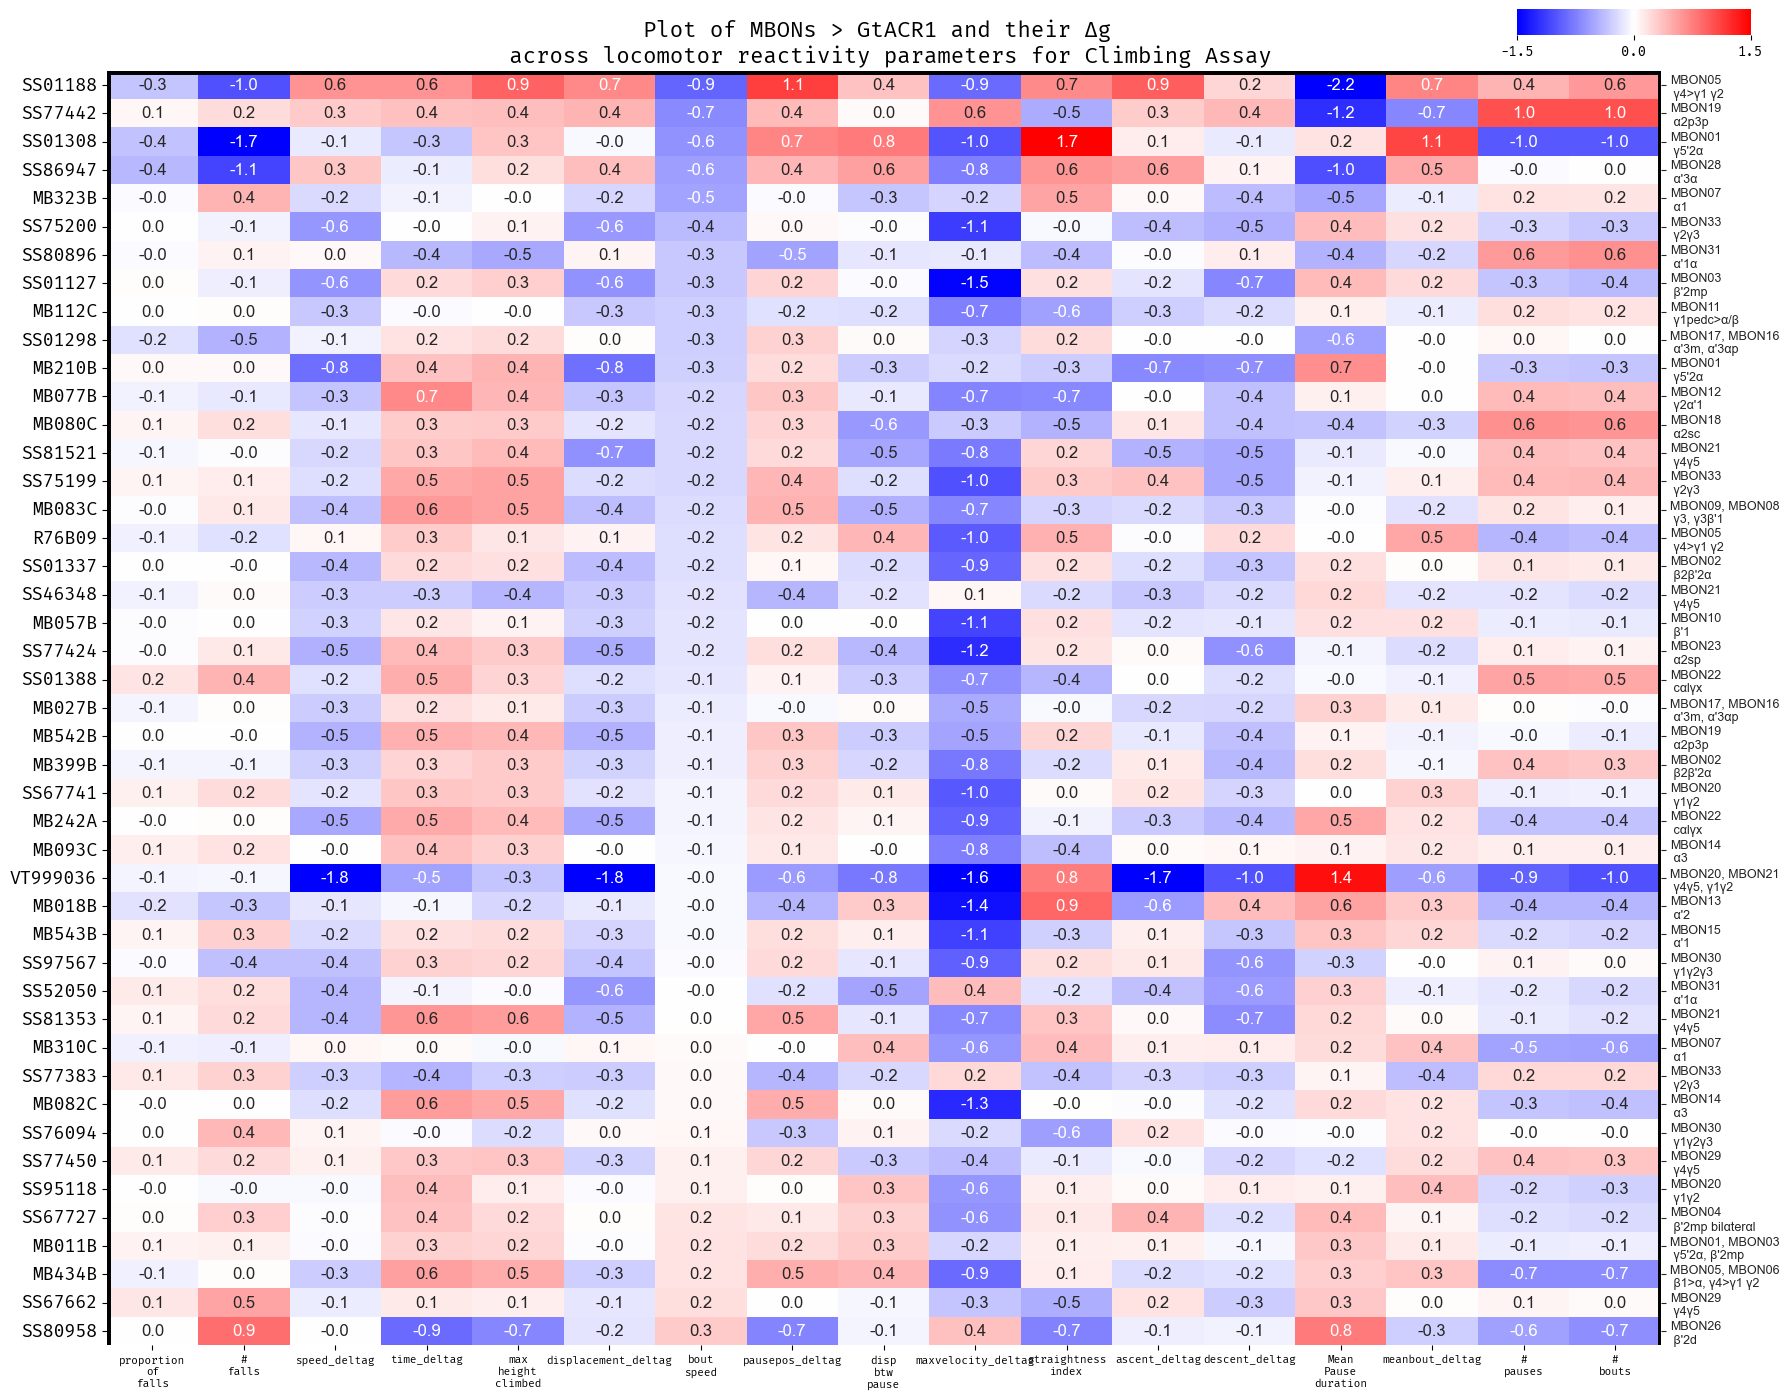

In [8]:
#mini list of only SPECIFIC responder
responder = "ACR"

dfoneresponder = mbononly.copy()

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = dfoneresponder[dfoneresponder['responder']=="Chrimson2"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = dfoneresponder[dfoneresponder['responder']=="ACR"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)

plt.rcParams["font.family"] = "Fira Mono"

df60 = df_specificmbon.set_index(['MBON'])
df60 = df60.drop(['responder'], axis =1)
fig1, ax4 = plt.subplots(figsize=(18, 14))     

#adding extra axes label
lobloclst = []
mbonloclst = []
for n in df_specificmbon['MBON']:
    df600 = df_specificmbon.copy()
    lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
    mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
df600['Lobe'] = lobloclst
df600['Name'] = mbonloclst

#df600 = df600.sort_values(by = "Name", ascending=True).reset_index(drop=True)
df60extra = df600.set_index('MBON').drop(['responder', 'Name', 'Lobe', 'genotypeandresponder'], axis = 1)   #change depending on parameters

newdf600 = pd.DataFrame()
naming = df600['Name'].to_frame().rename(columns = {"Name": ""})
lobing = df600['Lobe'].to_frame().rename(columns = {"Lobe": ""})
newlabel =(naming.values + "\n " + lobing.values).tolist()
newdf600['Merge'] = newlabel

xticklabeldf = df60extra.rename(columns={'bspeed_deltag': 'bout speed', 'pause_deltag': '# pauses', 'fallnumber_deltag': '# falls', 'meanpause_deltag': 'Mean Pause duration',
                                         'bout_deltag': '# bouts', 'displacementbetweenpause_deltag': 'disp btw pause',
                     'fallprop_deltag': "proportion of falls", 'straightindex_deltag': 'straightness index', 'height_deltag': 'max height climbed'})

xticklabellist = xticklabeldf.columns.tolist()

#colorbar
cax = inset_axes(ax4,
                 width="15%",  # width: 40% of parent_bbox width
                 height="2%",  # height: 10% of parent_bbox height
                 loc='lower right',
                 bbox_to_anchor=(0.04, 1.05, 1, 1),
                 bbox_transform=ax4.transAxes,
                 borderpad=-2,
                 )

sns.set_style("whitegrid", {'axes.grid' : False})    
       
j7 = sns.heatmap(df60extra, ax = ax4, annot=True, fmt=".1f", vmin = -1.5, vmax = 1.5, cmap='bwr', linewidths=0.0, edgecolor = "none",  xticklabels=xticklabellist, yticklabels=True,
                 clip_on=False, cbar_ax=cax, cbar_kws = dict(orientation = "horizontal", ticks = [-1.5,0,1.5]), annot_kws={"size": 12, }) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #cbar_kws = dict(orientation = "vertical")
#twilight_shifted also a possible color

j7.set_ylabel('')
j7.set_yticklabels(j7.get_yticklabels(), va='center', rotation = 0, fontsize = 13)
j7.set_xticklabels(j7.get_xticklabels(), rotation = 30, fontsize = 8)
wrap_labels(j7, 5)


# Drawing the frame 
j7.axhline(y = 0, color = 'k',  
            linewidth = 5) 
  
j7.axhline(y = 46, color = 'k', 
            linewidth = 5) 
  
j7.axvline(x = 0, color = 'k', 
            linewidth = 5) 
  
j7.axvline(x =17, color = 'k', 
            linewidth = 5) 

#secondary axes
j8 = j7.twinx()
j8.set_ylim([0,j7.get_ylim()[0]])
j8.set_yticks(j7.get_yticks())


#y labels for mbon lobes and naming
labellinglist = newdf600['Merge'].iloc[::-1]
labelledlist = []
for n in labellinglist:
    labelledlist.extend(n)
    #inserts blank space after every list name
j8.set_yticklabels(labelledlist, fontsize=9)
j8.spines['top'].set_visible(False)
j8.spines['right'].set_visible(False)
j8.spines['bottom'].set_visible(False)
j8.spines['left'].set_visible(False)

j7.set_title('Plot of MBONs > ' + responderrename +' and their Δg \n across locomotor reactivity parameters for Climbing Assay', x=0.5, weight='bold', fontsize =16)

fig1.tight_layout()

#plt.savefig(openPath + "images\\" + date + "_" + responder + "_deltagheatmapwithlobelocations.png", dpi = 1200)